# Exploratory Data Analysis (EDA) for Gaming subreddits

The analysis focuses on the three most popular games during that period (Dota 2, LoL, and CS:GO). 

### LIWC feature analysis
The LIWC feature analysis shows that these game subreddits exhibit similar normalized patterns.

Among the selected LIWC features which we expected to be highly relevant to gaming, **LIWC_SOC** (social process words e.g., talk, friend, share) and **LIWC_AFFECT** (emotion words) are the most dominant.

### Spikes and trends of dominant LIWC features during Esport tournaments
We also analyzed each game subreddit’s community activity during their corresponding esports tournaments.

We found that they **did not show clear spikes** in either the number of posts or the trends of dominant LIWC features during the tournaments period, unlike the politics subreddits, which showed clear spikes during major political events.

In [2]:
# Automatically reloads modules when you make changes (useful during development)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))

from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

In [4]:
df_esports.head(5)

,GameID,TournamentName,StartDate,EndDate,City,Country,TeamPlay,TotalUSDPrize,year
0,5079.0,Call of Duty Championship 2014,3/28/14,3/30/14,Los Angeles,United States,1.0,1000000.0,14.0
1,6418.0,The International 2014,7/8/14,7/21/14,Seattle/Washington,United States,1.0,10931103.0,14.0
2,7376.0,LoL 2014 World Championship,9/18/14,10/19/14,Taipei/Singapore,Taiwan/Singapore,1.0,2130000.0,14.0
3,9205.0,DAC 2015,1/5/15,2/9/15,Shangai,China,1.0,3057521.0,15.0
4,8885.0,Smite World Championship 2015,1/9/15,1/1/15,Atlanta,United States,1.0,2612259.0,15.0


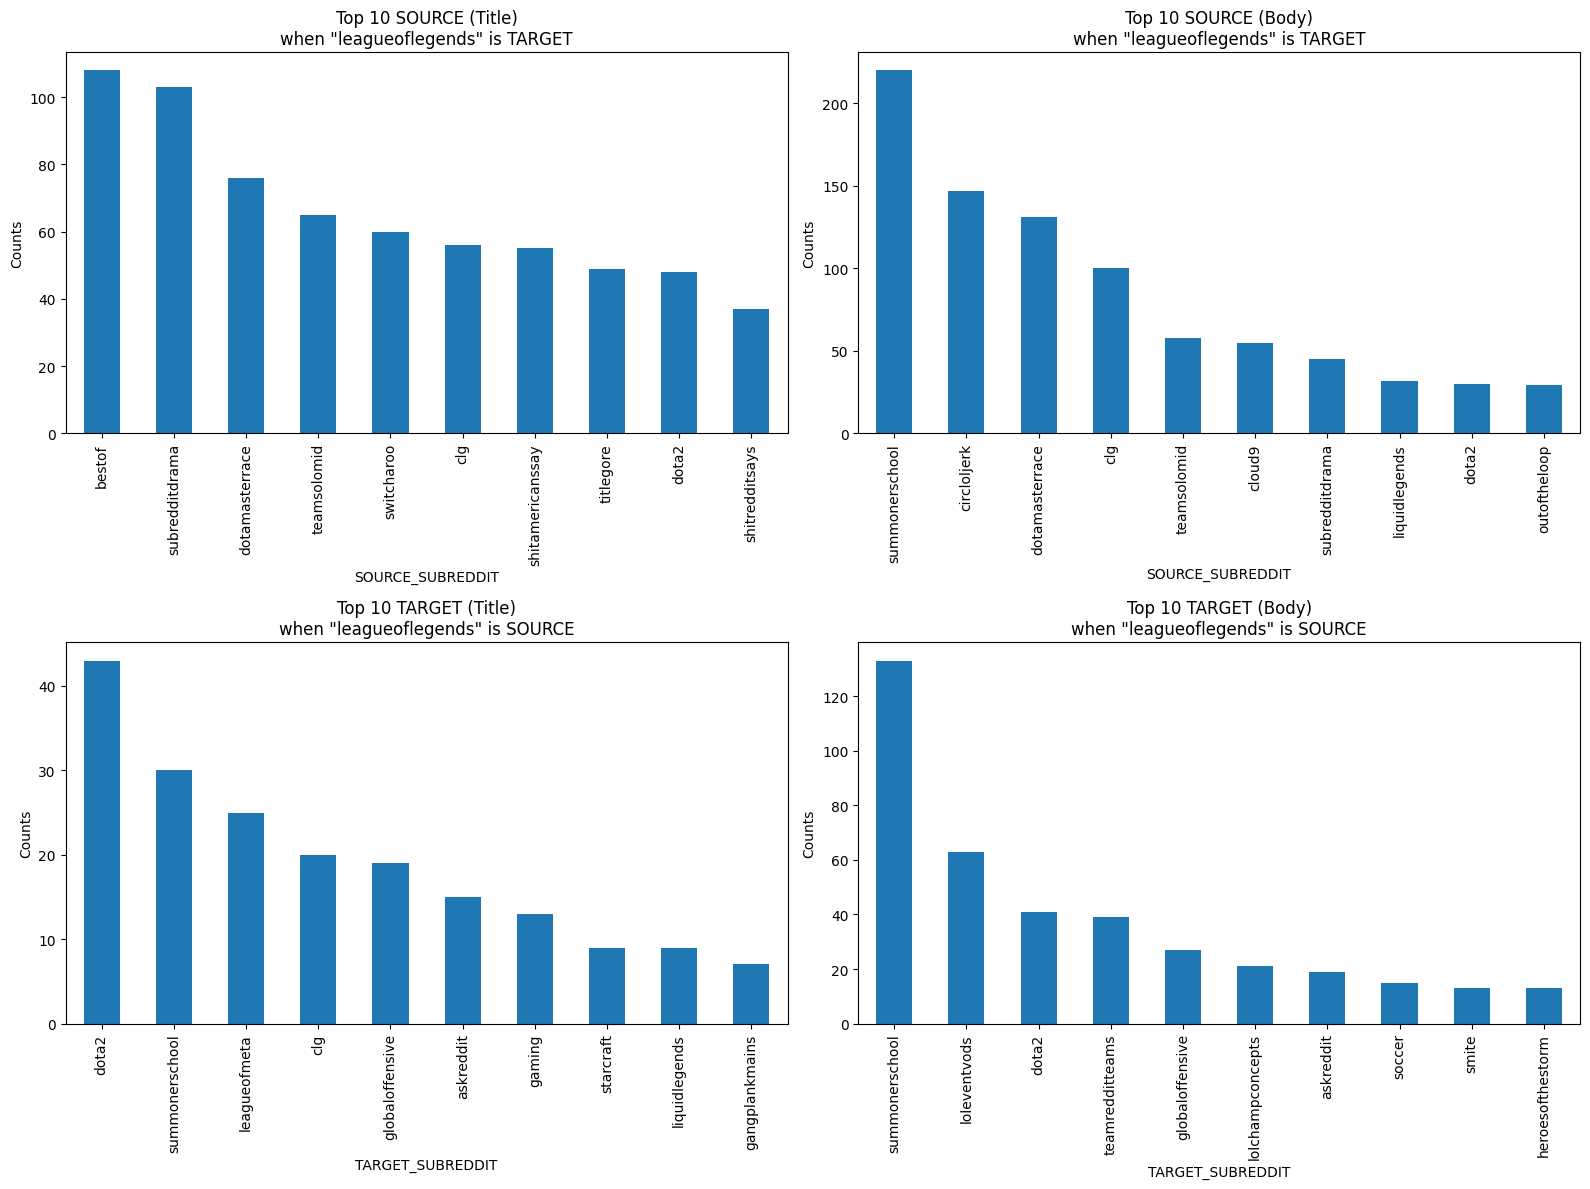

In [5]:
# subreddit = 'dota2'
subreddit = "leagueoflegends"
# subreddit = 'globaloffensive' # globaloffensive or csgo

top_10_source_title = df_title[df_title["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_title = df_title[df_title["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

top_10_source_body = df_body[df_body["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_body = df_body[df_body["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

plt.figure(figsize=(16, 12))

# 1. Source Title
plt.subplot(2, 2, 1)
top_10_source_title.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Title)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 2. Source Body
plt.subplot(2, 2, 2)
top_10_source_body.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Body)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 3. Target Title
plt.subplot(2, 2, 3)
top_10_target_title.plot(kind='bar')
plt.title(f'Top 10 TARGET (Title)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

# 4. Target Body
plt.subplot(2, 2, 4)
top_10_target_body.plot(kind='bar')
plt.title(f'Top 10 TARGET (Body)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()


Most popurlar games between 2014 and 2017 : dota2, league of legends, global offensive (cs:go)

In [6]:
games = ["gaming", "dota2", "leagueoflegends", "globaloffensive"]

dota2_subreddits = [
    'dota2', 'dota2circlejerk','dota2trade', 'learndota2', 'dota2betting', 
    'dotamasterrace', 'truedota2', 'dota2modding', 'dota2loungebets', 'redditdota2league',
]
lol_subreddits = [
    "leagueoflegends", "leagueoflegendsmeta", "summonerschool",  "clg", 
    "circloljerk", 'leagueconnect', 'lolesports'
    ]

globaloffensive_subreddits = [
    'globaloffensive', 'globaloffensivetrade', 'globaloffensivemarket',
    'csgo', 'csgojerk', 'csgobetting',
]

List of esports tournament during 2014-2017

In [7]:

dota2_tournament = [
    "The International 2014",
    "DAC 2015",
    "The International 2015",
    "The Frankfurt Major 2015",
    "World Cyber Arena 2015 (Dota 2)",
    "The Shanghai Major 2016",
    "The Manila Major 2016",
    "The International 2016",
    "Dota2 Professional League Season 2 - Top",
    "The Boston Major 2016",
    "World Cyber Arena 2016 (Dota 2)",
    "WESG 2016 (Dota 2)",
    "DAC 2017",
    "The Kiev Major 2017"
]

lol_tournament = [
    "LoL 2014 World Championship",
    "LoL 2015 World Championship",
    "LPL Spring 2016",
    "LPL Summer 2016",
    "LoL 2016 World Championship"
]

globaloffensive_tournament = [
    "MLG Major Championship: Columbus 2016",
    "ESL Pro League S3 Finals",
    "ELEAGUE Season 1",
    "Esports Championship Series Season 1 - Finals",
    "ESL One: Cologne 2016",
    "ELEAGUE Season 2",
    "ESL Pro League Season 4: Finals",
    "Esports Championship Series Season 2 - Finals",
    "WESG 2016 (CS:GO)",
    "ELEAGUE Major 2017"
]

Selected LIWC features related to humans, emotions, movement, and sensory experience (which are expected to be relevant to gaming communities)

In [8]:
selected_PROPERTIES = {
    "LIWC_SOC": "LIWC Social", # Social process words (talk, friend, share)
    "LIWC_FAM": "LIWC Family", # Family-related words
    "LIWC_FRIEND": "LIWC Friends", # Friends / peer-related words
    "LIWC_HUMAN": "LIWC Humans", # References to people / humans
    "LIWC_ACHIEV": "LIWC Achievement", # Achievement / goal words
    "LIWC_LEISURE": "LIWC Leisure", # Leisure and recreation words
    "LIWC_HOME": "LIWC Home", # Home / domestic words
    "LIWC_MONEY": "LIWC Money", # Money / finance words
    "LIWC_WORK": "LIWC Work", # Work and occupational words
    "LIWC_AFFECT": "LIWC Affect", # Emotion words
    "LIWC_POSEMO": "LIWC Pos. emotion", # Positive emotion words
    "LIWC_NEGEMO": "LIWC Neg. emotion", # Negative emotion words
    "LIWC_ANX": "LIWC Anxiety", # Anxiety-related words (nervous, afraid)
    "LIWC_ANGER": "LIWC Anger", # Anger-related words
    "LIWC_SAD": "LIWC Sadness", # Sadness-related words
    "LIWC_MOTION": "LIWC Motion", # Motion verbs (go, move, travel)
    "LIWC_SPACE": "LIWC Space", # Spatial / location words (left, above)
    "LIWC_PERCEPT": "LIWC Perceptual", # Perceptual processes (see, hear, feel)
    "LIWC_SEE": "LIWC See", # Vision-related words
    "LIWC_HEAR": "LIWC Hear", # Hearing-related words
    "LIWC_FEEL": "LIWC Feel", # Sensation / feeling words
}

### Sentiment andLIWC attributes

Length of selected properties: 21 ['LIWC_SOC', 'LIWC_FAM', 'LIWC_FRIEND', 'LIWC_HUMAN', 'LIWC_ACHIEV', 'LIWC_LEISURE', 'LIWC_HOME', 'LIWC_MONEY', 'LIWC_WORK', 'LIWC_AFFECT', 'LIWC_POSEMO', 'LIWC_NEGEMO', 'LIWC_ANX', 'LIWC_ANGER', 'LIWC_SAD', 'LIWC_MOTION', 'LIWC_SPACE', 'LIWC_PERCEPT', 'LIWC_SEE', 'LIWC_HEAR', 'LIWC_FEEL']


,Feature,Mean_Title,Max_Title,Sum_Title,Std_Title,Mean_Body,Max_Body,Sum_Body,Std_Body
0,LIWC_SOC,0.05832,0.67,742.84,0.07389,0.07403,0.32,565.66,0.03530
9,LIWC_AFFECT,0.04500,0.75,573.17,0.06376,0.04141,0.21,316.43,0.02909
8,LIWC_WORK,0.01425,0.43,181.56,0.03618,0.04031,0.33,308.00,0.02564
16,LIWC_SPACE,0.04307,0.40,548.57,0.05887,0.03912,0.25,298.95,0.02743
10,LIWC_POSEMO,0.02835,0.40,361.05,0.05040,0.02952,0.14,225.59,0.02403
5,LIWC_LEISURE,0.03446,0.50,438.89,0.05611,0.02071,0.17,158.22,0.02225
4,LIWC_ACHIEV,0.01597,0.33,203.45,0.03801,0.01673,0.16,127.83,0.01851
17,LIWC_PERCEPT,0.01134,0.60,144.42,0.03204,0.01302,0.11,99.48,0.01507
11,LIWC_NEGEMO,0.01663,0.75,211.80,0.04153,0.01176,0.14,89.89,0.01527
15,LIWC_MOTION,0.01105,0.40,140.77,0.03068,0.00980,0.12,74.88,0.01197


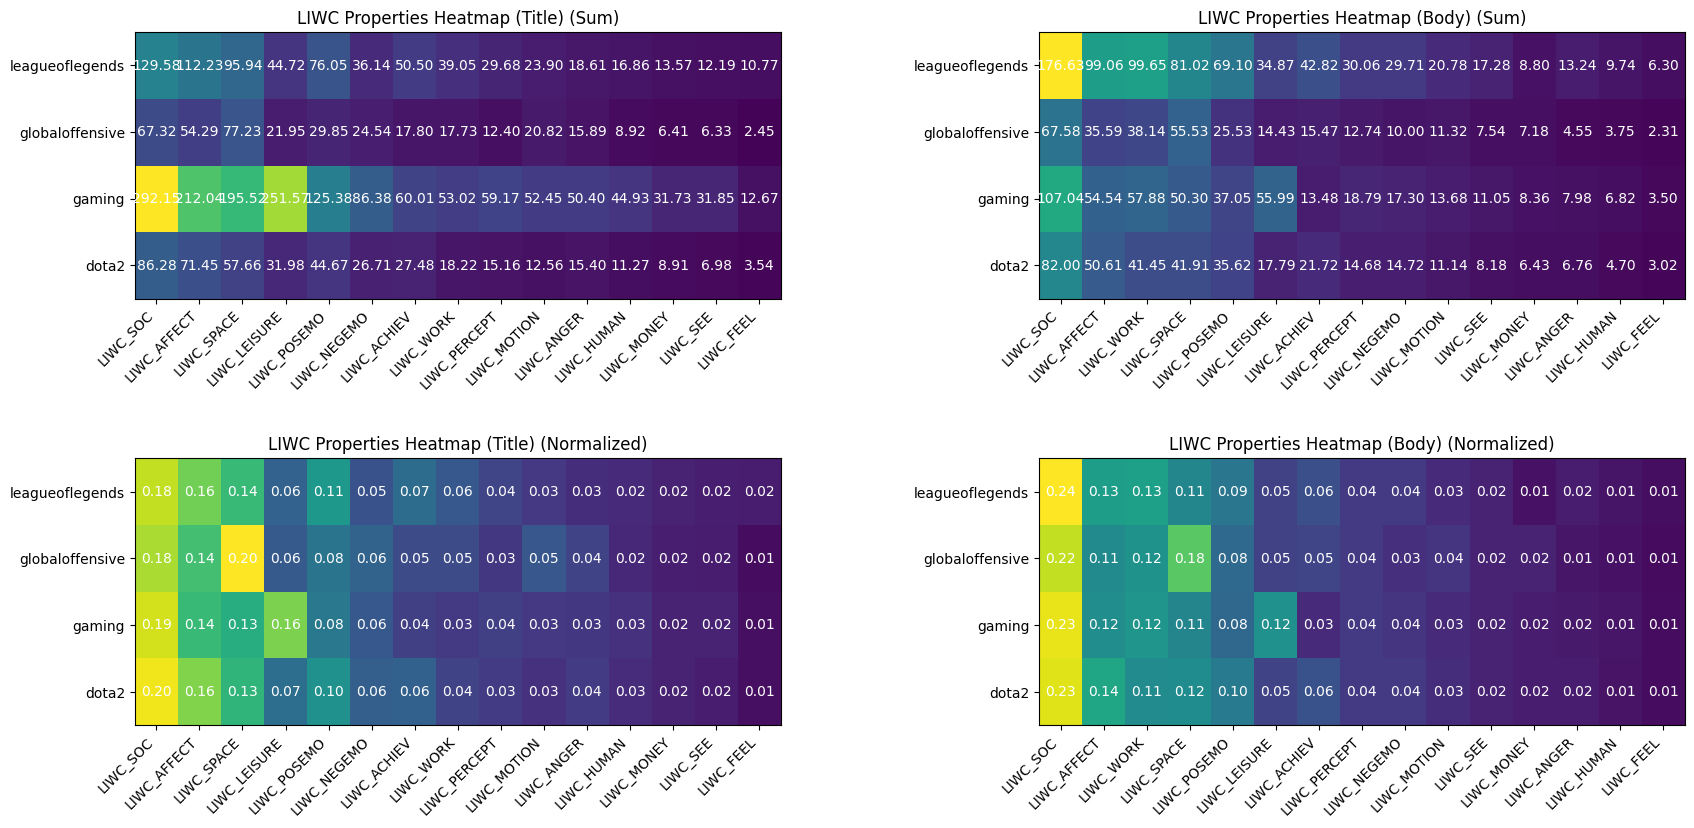

In [9]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list
from week1_Yuri import get_dataframe_features

print("Length of selected properties:", len(selected_PROPERTIES), list(selected_PROPERTIES.keys()))

subreddits_list = games
df_features = get_dataframe_features(
    df_title, df_body, selected_PROPERTIES.keys(), subreddits_list
)
display(df_features.sort_values(
    by=['Sum_Body', 'Sum_Title',], ascending=False
))

# VADER sentiment
# properties_list = [ "VADER_POS", "VADER_NEG", "VADER_COMP",]

# LIWC properties
properties_list_for_title = df_features.sort_values(
    by=['Sum_Title', 'Sum_Body', ], ascending=False
).head(15)["Feature"].tolist()

properties_list_for_body = df_features.sort_values(
    by=['Sum_Body', 'Sum_Title', ], ascending=False
).head(15)["Feature"].tolist()


fig, ax = plt.subplots(2, 2, figsize = (20, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plot_liwc_heatmaps_for_features_list(
    ax[0, 0], df_title, games, properties_list_for_title, title='LIWC Properties Heatmap (Title)')

plot_liwc_heatmaps_for_features_list(
    ax[0, 1], df_body, games, properties_list_for_body, title='LIWC Properties Heatmap (Body)')
plot_liwc_heatmaps_for_features_list(
    ax[1, 0], df_title, games, properties_list_for_title, title='LIWC Properties Heatmap (Title)', normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[1, 1], df_body, games, properties_list_for_body, title='LIWC Properties Heatmap (Body)', normalize=True)

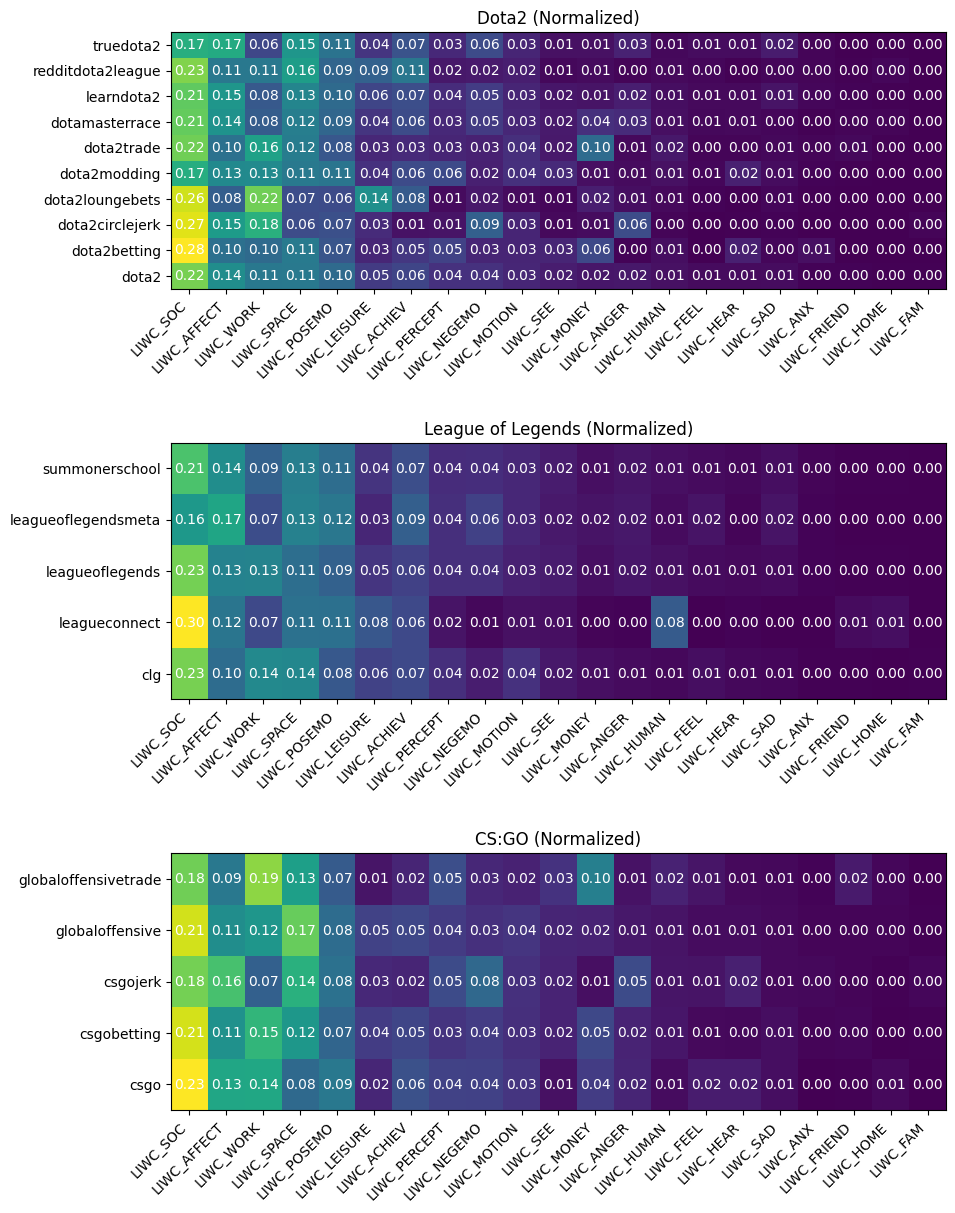

In [10]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list
properties_list_for_body = df_features.sort_values(
    by=['Sum_Body', 'Sum_Title', ], ascending=False
)["Feature"].tolist()

fig, ax = plt.subplots(3, 1, figsize = (10, 14))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plot_liwc_heatmaps_for_features_list(
    ax[0], df_body, dota2_subreddits, properties_list_for_body, title='Dota2',normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[1], df_body, lol_subreddits, properties_list_for_body, title='League of Legends', normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[2], df_body, globaloffensive_subreddits, properties_list_for_body, title='CS:GO'  , normalize=True)

### Spikes and trends of selected features over time for a given subreddits

====================== Dota2 related subreddits activity during Dota2 Tournaments ======================


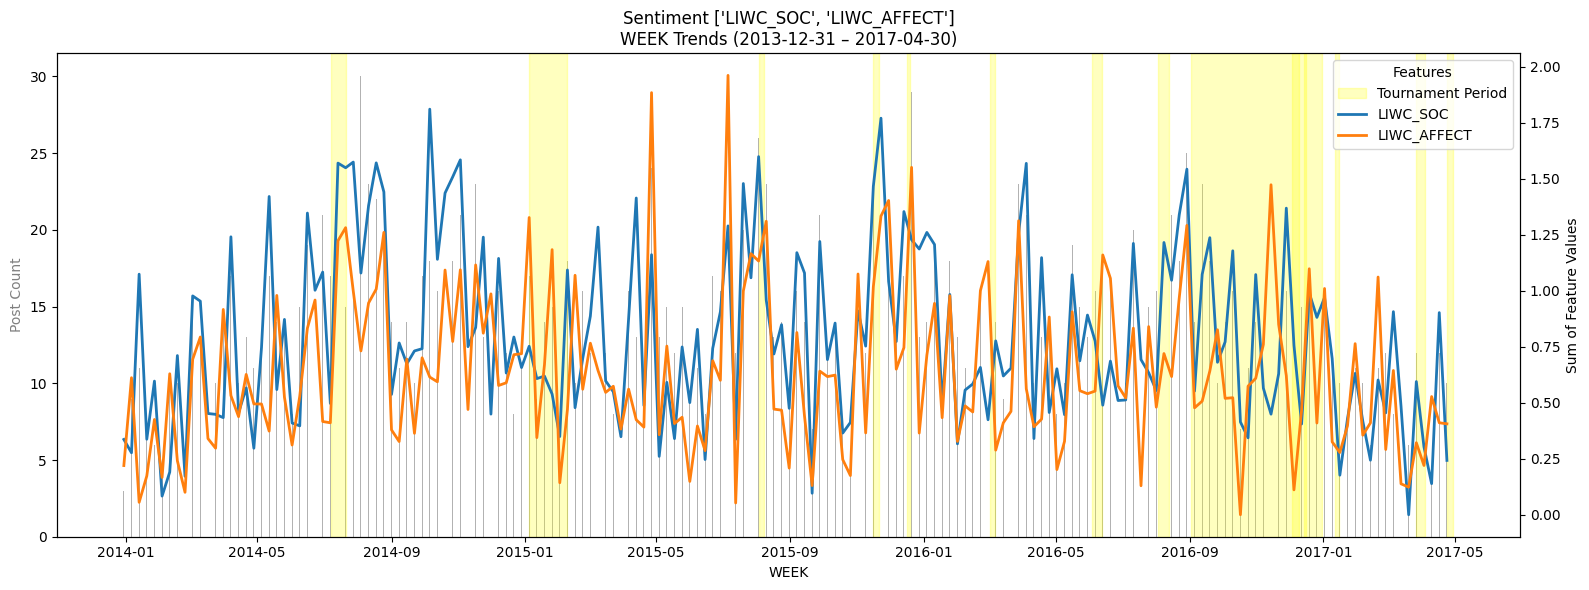

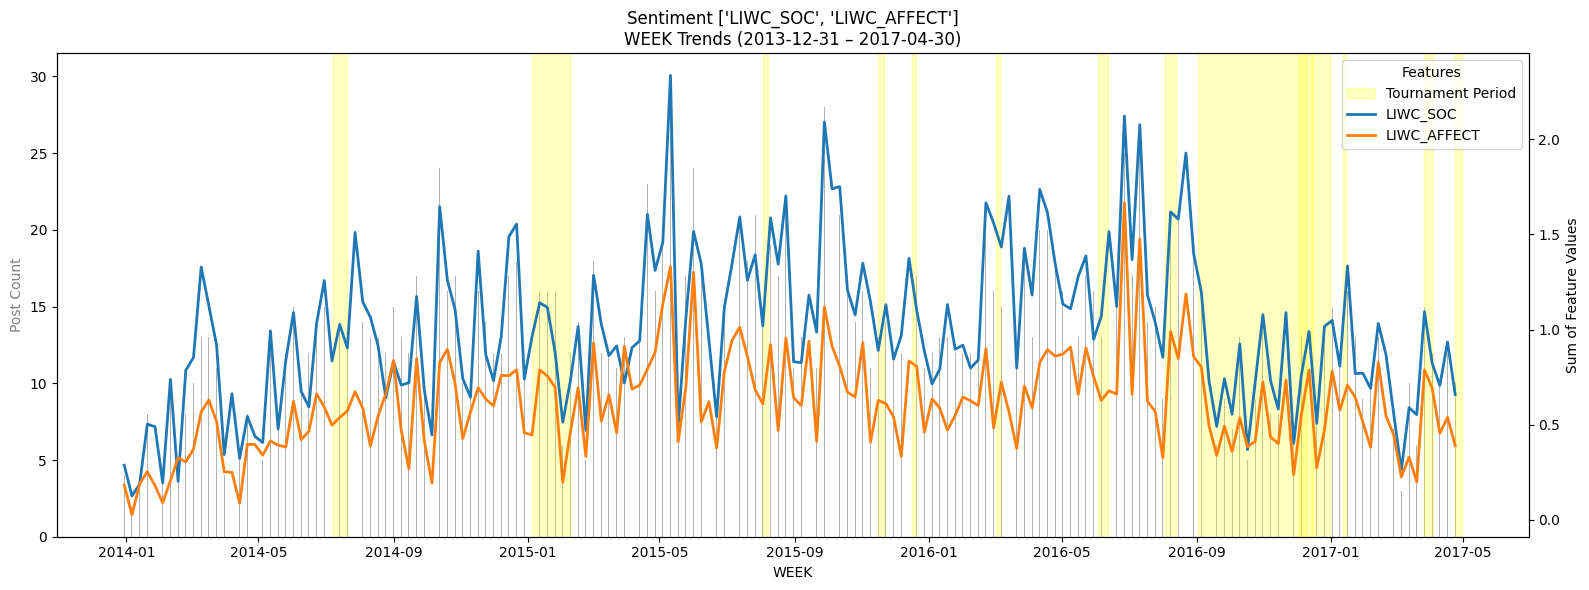

In [19]:
from datetime import datetime
from week1_Yuri import plot_subreddits_features_trend

games_list = {
    "Dota2" : { "subreddit": dota2_subreddits, "tournament": dota2_tournament},
    "LoL" : { "subreddit": lol_subreddits, "tournament": lol_tournament},
    "CSGO" : { "subreddit": globaloffensive_subreddits, "tournament": globaloffensive_tournament},
    }
game = "Dota2"
print(f"====================== {game} related subreddits activity during {game} Tournaments ======================")
subreddits_list = games_list[game]["subreddit"]
dates_list = list(df_esports.query(f"TournamentName in {games_list[game]['tournament']}")[["StartDate", "EndDate"]].itertuples(index=False, name=None))


formatted_dates=[(datetime.strptime(s,"%m/%d/%y").strftime("%Y-%m-%d"),
            datetime.strptime(e,"%m/%d/%y").strftime("%Y-%m-%d"))
           for s,e in dates_list]

features_list = ["LIWC_SOC",  "LIWC_AFFECT",]
                #  "LIWC_WORK", "LIWC_SPACE", "LIWC_LEISURE", "LIWC_POSEMO", "LIWC_NEGEMO"]

period = "W"

plot_subreddits_features_trend(
    df_title,
    subreddits_list,
    "2013-12-31",
    "2017-04-30",
    features_list,
    period,
    highlight_periods=formatted_dates    # add highlight ranges
)

plot_subreddits_features_trend(
    df_body,
    subreddits_list,
    "2013-12-31",
    "2017-04-30",
    features_list,
    period,
    highlight_periods=formatted_dates
)


The end of gaming EDA